# TITLE : 
**E-Commerce Recommendation System with Brazilian E-Commerce Public Dataset by Olist**

### Business Problem
E-commerce platforms memiliki ribuan produk
yang membuat customer kesulitan menemukan
produk relevan.

Project ini bertujuan membangun recommendation system
menggunakan collaborative filtering
untuk merekomendasikan produk
berdasarkan pola pembelian customer.

# BUILD RECOMMENDATION DATABASE

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


**Dataset Overview**

Dataset terdiri dari beberapa tabel:

- customers
  berisi data customer

- orders
  berisi transaksi order

- order_items
  berisi detail produk yang dibeli

- products
  berisi informasi produk

- reviews
  berisi review customer

Semua tabel akan digabungkan
untuk membangun interaction dataset.

In [2]:
# Load Dataset
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
order_items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
reviews = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')

print('customers   :', customers.shape)
print('orders      :', orders.shape)
print('order_items :', order_items.shape)
print('products    :', products.shape)
print('reviews     :', reviews.shape)

customers   : (99441, 5)
orders      : (99441, 8)
order_items : (112650, 7)
products    : (32951, 9)
reviews     : (99224, 7)


**Join Database**

In [3]:
# Join orders + order_items
df = orders.merge(order_items, on='order_id') # menghubungkan transaksi order dgn produk yang dibeli customers.

In [4]:
# Join products
df = df.merge(products, on='product_id') # menghubungkan detail produk yg dibeli customer 
                                         # ke tabel transaksi order dengan produk yg dibeli.


In [5]:
# Join reviews
df = df.merge(reviews, on='order_id') # menghubungkan review kepuasan produk dr customer terhadap 
                                      # yang di order.

In [6]:
# Join customers
df = df.merge(customers, on='customer_id') # menghubungkan data detail customer terhadap 
                                           # data produk + detail produk yang dibeli beserta review yg 
                                           # diberikan customers

# DATA UNDERSTANDING

In [7]:
# Lihat Struktur Dataset
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [8]:
# Cek Ukuran Dataset
print('Shape  :', df.shape)
print('Kolom  :', df.columns.tolist())

Shape  : (112372, 32)
Kolom  : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [9]:
# Cek Tipe Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112372 non-null  object 
 1   customer_id                    112372 non-null  object 
 2   order_status                   112372 non-null  object 
 3   order_purchase_timestamp       112372 non-null  object 
 4   order_approved_at              112357 non-null  object 
 5   order_delivered_carrier_date   111188 non-null  object 
 6   order_delivered_customer_date  110012 non-null  object 
 7   order_estimated_delivery_date  112372 non-null  object 
 8   order_item_id                  112372 non-null  int64  
 9   product_id                     112372 non-null  object 
 10  seller_id                      112372 non-null  object 
 11  shipping_limit_date            112372 non-null  object 
 12  price                         

In [10]:
# Cek Missing Value
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values:\n', missing)

Missing values:
 review_comment_title             98938
review_comment_message           64730
order_delivered_customer_date     2360
product_name_lenght               1598
product_category_name             1598
product_description_lenght        1598
product_photos_qty                1598
order_delivered_carrier_date      1184
product_length_cm                   18
product_width_cm                    18
product_weight_g                    18
product_height_cm                   18
order_approved_at                   15
dtype: int64


In [11]:
# Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

In [12]:
# Cek Data Review, Harga dan Biaya ongkir
df[['review_score', 'price', 'freight_value']].describe()

,review_score,price,freight_value
count,112372.000000,112372.000000,112372.000000
mean,4.032473,120.378962,19.977752
std,1.387849,182.152386,15.781421
min,1.000000,0.850000,0.000000
25%,4.000000,39.900000,13.070000
50%,5.000000,74.900000,16.250000
75%,5.000000,134.900000,21.150000
max,5.000000,6735.000000,409.680000


# EDA (EXPLORATORY DATA ANALYSIS)

**Top Produk Kategori**

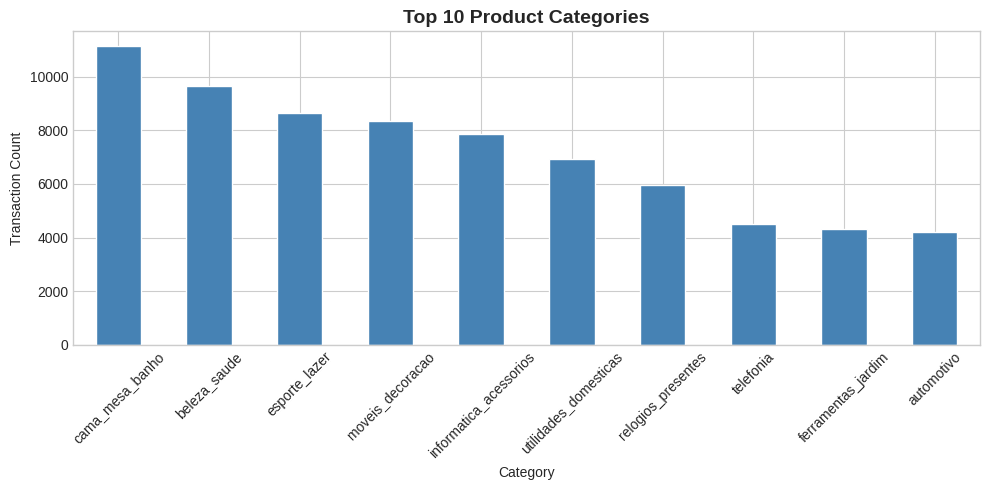

product_category_name
cama_mesa_banho           11137
beleza_saude               9645
esporte_lazer              8640
moveis_decoracao           8331
informatica_acessorios     7849
utilidades_domesticas      6943
relogios_presentes         5950
telefonia                  4517
ferramentas_jardim         4329
automotivo                 4213
Name: count, dtype: int64


In [13]:
# Top 10 kategori produk
top_category = df['product_category_name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_category.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Product Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Transaction Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(top_category)

**Insight** : Kategori dengan transaksi tertinggi
menunjukkan kategori produk
yang paling diminati customer.

**Review Score Distribution**

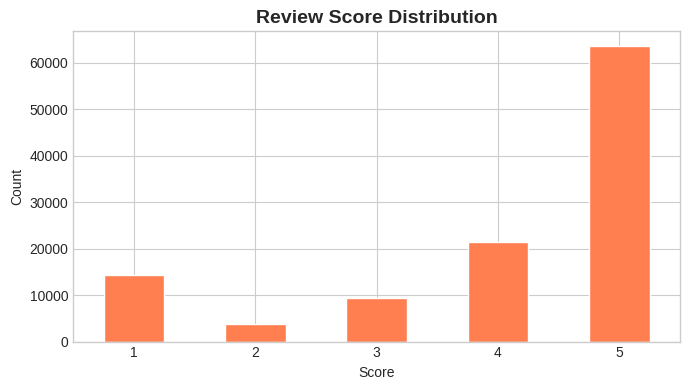

review_score
1    14235
2     3874
3     9423
4    21315
5    63525
Name: count, dtype: int64


In [14]:
# Review score distribution
review_dist = df['review_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
review_dist.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Review Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(review_dist)

**Insight** : Mayoritas customer memberikan
review score tinggi,
yang menunjukkan customer satisfaction
cukup baik.

In [ ]:
# Distribusi jumlah order per customer
orders_per_user = df.groupby('customer_unique_id')['order_id'].nunique()

print('Statistik order per customer:')
print(orders_per_user.describe())
print(f'\nCustomer dengan hanya 1 order : {(orders_per_user == 1).sum():,} ({(orders_per_user == 1).mean():.1%})')
print(f'Customer dengan >= 3 order    : {(orders_per_user >= 3).sum():,}')

fig, ax = plt.subplots(figsize=(8, 4))
orders_per_user.clip(upper=10).value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Orders per Customer (capped at 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Berapa banyak kategori unik per customer?
cats_per_user = df.groupby('customer_unique_id')['product_category_name'].nunique()
print('Kategori unik per customer:')
print(cats_per_user.describe())
print(f'\nCustomer beli hanya 1 kategori: {(cats_per_user == 1).mean():.1%}')

 # BUSINESS INSIGHT

1. **Ada 3 kategori produk yang jadi tulang punggung bisnis** — Perlengkapan rumah, kecantikan & kesehatan, dan olahraga menyumbang hampir sepertiga dari seluruh penjualan. Fokuskan anggaran promosi dan ketersediaan stok di ketiga kategori ini.

2. **Pelanggan puas, tapi tidak kembali** — Lebih dari 8 dari 10 pelanggan memberikan nilai kepuasan tinggi. Namun hampir semua dari mereka tidak pernah belanja lagi. Artinya pengalaman berbelanja sudah baik — yang kurang adalah alasan untuk kembali.

3. **97% pelanggan hanya belanja sekali seumur hidup** — Ini adalah angka yang sangat tinggi. Bisnis terus-menerus bergantung pada pelanggan baru, padahal mempertahankan pelanggan lama jauh lebih murah daripada mencari pelanggan baru.

4. **Tidak ada yang mengingatkan pelanggan untuk kembali** — Setelah transaksi selesai, tidak ada sentuhan lanjutan. Notifikasi, email rekomendasi, atau voucher sederhana setelah pengiriman bisa menjadi cara murah untuk mendatangkan transaksi kedua.

5. **Pelanggan yang kecewa perlu penanganan terpisah** — Sekitar 1 dari 6 transaksi mendapat penilaian buruk. Pelanggan ini membutuhkan pendekatan berbeda — jangan tawarkan produk serupa, tapi tunjukkan bahwa keluhan mereka didengar.

6. **Sistem rekomendasi belum bisa bekerja optimal** — Karena hampir semua pelanggan hanya beli satu kali, sistem kesulitan mempelajari pola belanja. Semakin banyak pelanggan yang repeat purchase, semakin cerdas rekomendasi produk yang bisa diberikan.

7. **Peluang bundling produk masih besar** — Pelanggan yang membeli perlengkapan rumah kemungkinan besar juga membutuhkan produk dekorasi atau peralatan rumah tangga. Menawarkan produk pelengkap saat checkout bisa meningkatkan nilai transaksi per pelanggan.

8. **Pertumbuhan bisnis jangka panjang bergantung pada retensi** — Mendorong pelanggan untuk belanja kedua dan ketiga adalah investasi terbaik saat ini — bukan hanya untuk revenue, tapi juga untuk membuat sistem rekomendasi semakin akurat dari waktu ke waktu.

# DATA CLEANING AND PREPARATION

In [ ]:
# Pilih kolom yang relevan
rec_df = df[[
    'customer_unique_id',
    'product_id',
    'product_category_name',
    'review_score'
]].dropna().copy()

print('Shape setelah dropna:', rec_df.shape)

In [ ]:
# Filter 1: Hapus user dengan transaksi < 3
user_counts = rec_df['customer_unique_id'].value_counts()
active_users = user_counts[user_counts >= 3].index
rec_df = rec_df[rec_df['customer_unique_id'].isin(active_users)]

print(f'Setelah filter user >= 3 transaksi: {rec_df.shape}')
print(f'Jumlah user aktif: {rec_df["customer_unique_id"].nunique():,}')

In [ ]:
# Filter 2: Hapus kategori yang dibeli < 5 user unik
cat_user_counts = rec_df.groupby('product_category_name')['customer_unique_id'].nunique()
valid_categories = cat_user_counts[cat_user_counts >= 5].index
rec_df = rec_df[rec_df['product_category_name'].isin(valid_categories)]

print(f'Setelah filter kategori >= 5 user : {rec_df.shape}')
print(f'Jumlah kategori valid             : {rec_df["product_category_name"].nunique():,}')

In [ ]:
# Buat interaction dataframe: agregasi review_score per (user, category)
# Menggunakan mean score sebagai bobot interaksi 
interaction_df = (
    rec_df
    .groupby(['customer_unique_id', 'product_category_name'])['review_score']
    .mean()
    .reset_index(name='score')
)

print('Interaction df shape:', interaction_df.shape)
interaction_df.head()

In [ ]:
# User-Category Matrix (weighted by review_score)
user_category_matrix = interaction_df.pivot_table(
    index='customer_unique_id',
    columns='product_category_name',
    values='score',
    fill_value=0
)

print('User-Category Matrix shape:', user_category_matrix.shape)

sparsity = 1.0 - np.count_nonzero(user_category_matrix.values) / user_category_matrix.size
print(f'Sparsity                  : {sparsity:.4f} ({sparsity*100:.2f}%)')
print('\n(Sparsity rendah = lebih banyak data overlap = rekomendasi lebih baik)')

# MODELING

**Kenapa SVD, bukan KNN langsung?**  
KNN cosine pada sparse matrix menghasilkan skor mendekati 0 karena hampir semua pasangan vektor saling tegak lurus (tidak ada overlap).  
SVD memampatkan matriks sparse ke *latent space* berdimensi rendah (dense), sehingga cosine similarity bisa menemukan pola tersembunyi.

In [ ]:
#  Transpose: item (category) × user  (cari kesamaan antar kategori)
category_matrix = user_category_matrix.T  # shape: (n_categories, n_users)

# Pilih n_components (dimensi latent space)
# Aturan: min(n_categories, n_users) // 4, maksimal 100
n_components = min(50, min(category_matrix.shape) - 1)
print(f'n_components yang digunakan: {n_components}')

# Fit Truncated SVD
svd = TruncatedSVD(n_components=n_components, random_state=42)
category_latent = svd.fit_transform(category_matrix)

print(f'Explained variance ratio  : {svd.explained_variance_ratio_.sum():.4f} ({svd.explained_variance_ratio_.sum()*100:.2f}%)')
print(f'Category latent matrix    : {category_latent.shape}')

In [ ]:
# Hitung Cosine Similarity di latent space

# Normalisasi agar cosine = dot product
category_latent_norm = normalize(category_latent, norm='l2')
similarity_matrix = cosine_similarity(category_latent_norm)

# Bungkus dalam DataFrame dengan label kategori
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_matrix.index,
    columns=category_matrix.index
)

print('Similarity matrix shape:', similarity_df.shape)
print(f'\nContoh skor similarity (5 baris pertama):')
similarity_df.iloc[:5, :5].round(4)

In [ ]:
# Fungsi Rekomendasi Kategori (Collaborative Filtering via SVD)

def recommend_categories_svd(category_name, n=5, verbose=True):
    
    if category_name not in similarity_df.index:
        print(f'Kategori "{category_name}" tidak ditemukan.')
        return None

    scores = (
        similarity_df[category_name]
        .drop(index=category_name)     # exclude diri sendiri
        .sort_values(ascending=False)
        .head(n)
    )

    result = scores.reset_index()
    result.columns = ['category', 'similarity_score']
    result['similarity_score'] = result['similarity_score'].round(4)
    result.index += 1

    if verbose:
        print(f'\n🔍 Top {n} kategori serupa dengan "{category_name}":')
        print(result.to_string())

    return result


# Test dengan kategori pertama
sample_cat = category_matrix.index[0]
print(f'Sample kategori : {sample_cat}')
recommend_categories_svd(sample_cat, n=5)

- 
    Rekomendasikan kategori serupa berdasarkan pola pembelian customer.
    
    Parameters
    ----------
    category_name : str  — nama kategori input
    n             : int  — jumlah rekomendasi
    verbose       : bool — tampilkan tabel hasil

    Returns
    -------
    pd.DataFrame  — kolom: category, similarity_score


In [ ]:
# Bandingkan skor similarity: SVD vs KNN 
from sklearn.neighbors import NearestNeighbors

# KNN lama (binary, sparse)
old_matrix = user_category_matrix.copy()
old_matrix[old_matrix > 0] = 1   # paksa binary seperti versi KNN
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(old_matrix.T)

q_idx = list(old_matrix.columns).index(sample_cat)
distances_knn, _ = knn_model.kneighbors(
    old_matrix.T.iloc[q_idx].values.reshape(1, -1), n_neighbors=6
)
sim_knn = 1 - distances_knn.flatten()[1:]  # cosine distance -> similarity

# SVD
sim_svd = similarity_df[sample_cat].drop(index=sample_cat).sort_values(ascending=False).head(5).values

print(f'Perbandingan similarity score untuk kategori: {sample_cat}')
print(f'{"":5} {"KNN":>15} {"SVD":>15}')
print('-' * 38)
for i, (k, s) in enumerate(zip(sim_knn, sim_svd), 1):
    print(f'Top {i}  {k:>15.4f} {s:>15.4f}')
print(f'\nSVD menghasilkan similarity score yang jauh lebih informatif!')

# EVALUASI MODEL

In [ ]:
# Train/Test Split per interaksi
train_df, test_df = train_test_split(interaction_df, test_size=0.2, random_state=42)

print(f'Train size : {len(train_df):,}')
print(f'Test size  : {len(test_df):,}')

In [ ]:
# ── Fungsi Evaluasi Precision@K dan Recall@K

def evaluate_at_k(test_data, sim_matrix, k=5, n_sample=500):

    # Ambil user yang ada di test dan train
    test_users  = test_data['customer_unique_id'].unique()
    train_users = train_df['customer_unique_id'].unique()
    common_users = list(set(test_users) & set(train_users))

    # Sample untuk efisiensi
    sample_users = np.random.choice(common_users, size=min(n_sample, len(common_users)), replace=False)

    precisions, recalls = [], []

    for uid in sample_users:
        actual_cats = set(test_data[test_data['customer_unique_id'] == uid]['product_category_name'])
        train_cats  = list(train_df[train_df['customer_unique_id'] == uid]['product_category_name'])

        if not actual_cats or not train_cats:
            continue

        # Seed: kategori terakhir yang dibeli di train
        seed_cat = train_cats[-1]
        if seed_cat not in sim_matrix.index:
            continue

        recommended = (
            sim_matrix[seed_cat]
            .drop(index=seed_cat)
            .sort_values(ascending=False)
            .head(k)
            .index.tolist()
        )

        hits = len(set(recommended) & actual_cats)
        precisions.append(hits / k)
        recalls.append(hits / len(actual_cats) if actual_cats else 0)

    return {
        'precision@k': np.mean(precisions),
        'recall@k'   : np.mean(recalls),
        'n_evaluated': len(precisions)
    }


# Jalankan evaluasi untuk K = 5 dan K = 10
for k in [5, 10]:
    result = evaluate_at_k(test_df, similarity_df, k=k)
    print(f'K={k:2d} | Precision@K: {result["precision@k"]:.4f} | Recall@K: {result["recall@k"]:.4f} | n_eval: {result["n_evaluated"]}')

    Evaluasi model dengan Precision@K dan Recall@K.
     
    Strategi:
    - Untuk setiap user di test set, ambil kategori yang dia beli
    - Ambil salah satu kategori dari train sebagai seed
    - Rekomendasikan K kategori teratas
    - Hitung overlap dengan kategori aktual di test


In [ ]:
# Catalog Coverage: berapa % kategori pernah direkomendasikan?
all_categories = set(similarity_df.index)
recommended_set = set()

# Simulasikan rekomendasi untuk semua kategori
for cat in all_categories:
    top_recs = similarity_df[cat].drop(index=cat).sort_values(ascending=False).head(10).index
    recommended_set.update(top_recs)

coverage = len(recommended_set) / len(all_categories)
print(f'Total kategori        : {len(all_categories)}')
print(f'Kategori direkomendasikan: {len(recommended_set)}')
print(f'Catalog Coverage      : {coverage:.4f} ({coverage*100:.2f}%)')

In [ ]:
# Visualisasi: Heatmap similarity antar 15 kategori teratas
top15_cats = rec_df['product_category_name'].value_counts().head(15).index.tolist()

# Filter hanya kategori yang ada di similarity_df
top15_cats = [c for c in top15_cats if c in similarity_df.index]

sim_subset = similarity_df.loc[top15_cats, top15_cats]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(top15_cats), dtype=bool)  # sembunyikan diagonal
sns.heatmap(
    sim_subset,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Category Similarity Matrix (Top 15 Categories)', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Popularity-Based Recommendation
Cold Start Handler

In [ ]:
# Hitung skor popularitas: gabungkan frekuensi + rata-rata review
popularity_df = (
    rec_df
    .groupby('product_category_name')
    .agg(
        total_purchase=('customer_unique_id', 'count'),
        avg_score=('review_score', 'mean'),
        unique_buyers=('customer_unique_id', 'nunique')
    )
    .reset_index()
)

# Normalized popularity score (0–1)
popularity_df['norm_purchase'] = (
    popularity_df['total_purchase'] / popularity_df['total_purchase'].max()
)
popularity_df['norm_score'] = (
    popularity_df['avg_score'] / popularity_df['avg_score'].max()
)

# Gabungkan: 70% frekuensi + 30% rating
popularity_df['popularity_score'] = (
    0.7 * popularity_df['norm_purchase'] +
    0.3 * popularity_df['norm_score']
)

popularity_df = popularity_df.sort_values('popularity_score', ascending=False).reset_index(drop=True)
popularity_df.index += 1

print('Top 10 kategori populer:')
popularity_df[['product_category_name', 'total_purchase', 'avg_score', 'popularity_score']].head(10)

# Hybrid Recommendation System

Gabungkan collaborative filtering (SVD) + popularity-based:  
- **User dikenal** → SVD similarity + bobot popularitas  
- **User baru (cold-start)** → fallback ke top-N popularitas

In [ ]:
# Buat lookup popularitas untuk blending
pop_scores = popularity_df.set_index('product_category_name')['popularity_score'].to_dict()


def hybrid_recommend(category_name=None, n=5, cf_weight=0.7, pop_weight=0.3):
    
    if category_name is None or category_name not in similarity_df.index:
        # Cold-start: kembalikan top-N berdasarkan popularitas saja
        result = popularity_df.head(n)[['product_category_name', 'popularity_score']].copy()
        result.columns = ['category', 'hybrid_score']
        result['note'] = 'cold-start (popularity-based)'
        print(f'[Cold-start] Rekomendasi berdasarkan popularitas:')
        print(result.to_string(index=False))
        return result

    # Collaborative filtering scores
    cf_scores = (
        similarity_df[category_name]
        .drop(index=category_name)
        .sort_values(ascending=False)
        .head(n * 3)   # ambil lebih banyak dulu untuk re-ranking
    )

    # Blend dengan popularitas
    blended = []
    for cat, cf_s in cf_scores.items():
        p_s = pop_scores.get(cat, 0)
        blended.append({
            'category'         : cat,
            'cf_score'         : round(cf_s, 4),
            'popularity_score' : round(p_s, 4),
            'hybrid_score'     : round(cf_weight * cf_s + pop_weight * p_s, 4)
        })

    result = (
        pd.DataFrame(blended)
        .sort_values('hybrid_score', ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    result.index += 1

    print(f'\n🎯 Hybrid Recommendation untuk "{category_name}" (CF {cf_weight} + Pop {pop_weight}):')
    print(result.to_string())
    return result


# Test 1: User dengan kategori diketahui
hybrid_recommend(sample_cat, n=5)


    Hybrid Recommendation: CF (SVD) + Popularity-based.

    Parameters
    ----------
    category_name : str or None — kategori seed. None = cold-start (pure popularity)
    n             : int         — jumlah rekomendasi
    cf_weight     : float       — bobot collaborative filtering (default 0.7)
    pop_weight    : float       — bobot popularitas (default 0.3)

    Returns
    -------
    pd.DataFrame — kolom: category, cf_score, popularity_score, hybrid_score
    """

In [ ]:
# Test 2: Cold-start (user baru, tidak ada riwayat)
hybrid_recommend(category_name=None, n=5)

In [ ]:
# Test 3: Beberapa kategori lain
test_categories = list(category_matrix.index[:3])
for cat in test_categories:
    hybrid_recommend(cat, n=3)

# SAVE MODEL & ARTIFACTS

In [ ]:
import pickle

# Simpan SVD model
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd, f)

# Simpan similarity matrix
similarity_df.to_csv('category_similarity_matrix.csv')

# Simpan popularity scores
popularity_df.to_csv('category_popularity.csv', index=False)

# Simpan user-category matrix
user_category_matrix.to_csv('user_category_matrix.csv')

print('Semua artefak berhasil disimpan:')
print('  • svd_model.pkl')
print('  • category_similarity_matrix.csv')
print('  • category_popularity.csv')
print('  • user_category_matrix.csv')

# BUSINESS RECOMMENDATION

1. **Tampilkan rekomendasi produk yang relevan kepada setiap pembeli** — Sistem rekomendasi yang sudah dibangun mampu mengenali pola belanja pelanggan dan menyarankan kategori produk yang kemungkinan besar dibutuhkan selanjutnya. Fitur ini sebaiknya ditampilkan di halaman setelah checkout atau di email konfirmasi pengiriman.

2. **Prioritaskan 5 kategori terlaris sebagai rekomendasi utama** — Data menunjukkan bahwa perlengkapan rumah (moveis_decoracao, cama_mesa_banho), aksesori komputer, peralatan rumah tangga, dan olahraga adalah kategori paling diminati. Pelanggan baru yang belum memiliki riwayat belanja sebaiknya langsung ditampilkan produk dari kategori ini.

3. **Manfaatkan kepuasan pelanggan untuk mendorong transaksi kedua** — 83% pelanggan memberikan nilai kepuasan tinggi, namun 97% tidak pernah kembali berbelanja. Kirimkan voucher atau penawaran khusus 7–14 hari setelah barang diterima. Biaya akuisisi pelanggan lama jauh lebih murah dibanding mencari pelanggan baru.

4. **Jangan rekomendasikan produk serupa kepada pelanggan yang kecewa** — Sekitar 17% transaksi mendapat nilai rendah (bintang 1–2). Sistem sudah dirancang untuk membobot kepuasan ini — pelanggan yang memberi nilai buruk tidak akan mendapat rekomendasi dari kategori yang sama.

5. **Gunakan data belanja untuk menawarkan produk pelengkap** — Model menunjukkan bahwa pelanggan yang membeli perlengkapan rumah cenderung juga membutuhkan peralatan dekorasi atau rumah tangga. Fitur "produk yang sering dibeli bersamaan" bisa langsung meningkatkan nilai rata-rata per transaksi.

6. **Perbarui sistem rekomendasi setiap bulan** — Pola belanja pelanggan berubah seiring waktu dan musim. Sistem yang diperbarui rutin akan terus memberikan saran yang relevan dan tidak ketinggalan tren.

7. **Kumpulkan lebih banyak data perilaku pelanggan** — Saat ini sistem hanya belajar dari transaksi yang terjadi. Jika platform bisa merekam produk yang diklik, dimasukkan ke keranjang, atau di-wishlist, kualitas rekomendasi akan meningkat signifikan meskipun pelanggan belum membeli.

8. **Semakin banyak pelanggan loyal, semakin cerdas sistemnya** — Sistem rekomendasi bekerja lebih baik seiring bertambahnya data. Setiap pelanggan yang berhasil didorong untuk belanja kedua dan ketiga secara langsung membuat rekomendasi untuk semua pelanggan lain menjadi lebih akurat.